# AI Logits Visualiser

## Importing the libraries

In [1]:
import os
import math
import networkx as nx
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import OpenAI
from typing import List, Dict

## Loading OpenAI API Key

In [2]:
load_dotenv(override = True)
api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    print("No API key found!")
else:
    print("API key found!")

API key found!


## Creating Token Predictor Class

In [3]:
class TokenPredictor:

    def __init__(self, model_name: str):
        self.client = OpenAI()
        self.messages = []
        self.prediction = []
        self.model_name = model_name

    def predict_tokens(self, prompt: str, max_tokens: int = 100) -> List[Dict]:

        response = self.client.chat.completions.create(
            model = self.model_name,
            messages = [{"role": "user", "content": prompt}],
            max_completion_tokens = max_tokens,
            temperature = 0.0,
            logprobs = True,
            top_logprobs = 3,
            stream = True
        )

        predictions = []

        for chunk in response:
            if chunk.choices[0].delta.content:

                token = chunk.choices[0].delta.content
                logprobs = chunk.choices[0].logprobs.content[0].top_logprobs

                logprobs_dict = {
                    item.token: item.logprob for item in logprobs
                }

                top_token = token
                top_prob = logprobs_dict[token]

                alternatives = []
                for alt_token, alt_prob in logprobs_dict.items():
                    if alt_token != token:
                        alternatives.append((
                            alt_token,
                            math.exp(alt_prob),
                        ))

                alternatives.sort(key = lambda x: x[1], reverse = True)

                prediction = {
                    "token": top_token,
                    "probability": math.exp(top_prob),
                    "alternatives": alternatives[:2]
                }

                predictions.append(prediction)
        
        return predictions

## Creating Graph Function

In [8]:
def create_graph(model_name: str, prediction: List[Dict]) -> nx.DiGraph:

    G = nx.DiGraph()
    G.add_node(
        "START",
        token = model_name,
        prob = "START",
        color = "lightgreen",
        size = 10000
    )

    for idx, pred in enumerate(prediction):
        
        token_id = f"t{idx}"
        G.add_node(
            token_id,
            token = pred["token"],
            prob = f"{pred['probability'] * 100:.2f}%",
            color = "lightblue",
            size = 6000
        )

        if idx == 0:
            G.add_edge("START", token_id)
        else:
            G.add_edge(f"t{idx - 1}", token_id)

    last_id = None

    for i, pred in enumerate(prediction):   

        parent_token = f"t{i}"
        
        for j, (alt_token, alt_prob) in enumerate(pred["alternatives"]):

            alt_id = f"t{i}_alt{j}"
            G.add_node(
                alt_id,
                token = alt_token,
                prob = f"{alt_prob * 100:.2f}%",
                color = "lightgray",
                size = 6000
            )

            G.add_edge(parent_token, alt_id)

    last_id = f"t{len(prediction) - 1}"

    G.add_node(
        "END",
        token = "END",
        prob = "100%",
        color = "red",
        size = 6000
    )

    G.add_edge(last_id, "END")
    
    return G

## Creating Visualise Function

In [5]:
def visualise(G: nx.DiGraph, figsize = (14, 80)):

    plt.figure(figsize = figsize)

    position = {}
    spacing_x = 5
    spacing_y = 5

    main_node = [n for n in G.nodes() if "_alt" not in n]

    for idx, node in enumerate(main_node):
        position[node] = (0, -idx * spacing_y)

    for node in G.nodes():

        if "_alt" in node:
            main_token = node.split("_")[0]
            alt_num = int(node.split("_alt")[1])

            if main_token in position:
                x_offset = -spacing_x if alt_num == 0 else spacing_x
                position[node] = (x_offset, position[main_token][1] + 0.05)

    node_color = [G.nodes[node]["color"] for node in G.nodes()]
    node_size = [G.nodes[node]["size"] for node in G.nodes()]
    labels = {node: f"{G.nodes[node]['token']}\n{G.nodes[node]['prob']}" for node in G.nodes()}

    nx.draw_networkx_nodes(
        G,
        position,
        node_color = node_color,
        node_size = node_size
    )

    nx.draw_networkx_edges(
        G,
        position,
        edge_color = "gray",
        arrows = True,
        arrowsize = 20,
        alpha = 0.7
    )

    nx.draw_networkx_labels(
        G,
        position,
        labels,
        font_size =14
    )

    plt.title("Token prediction.")
    plt.axis("off")

    x_values = [x for x, y in position.values()]
    y_values = [y for x, y in position.values()]

    margin = 8

    plt.xlim(min(x_values) - margin, max (x_values) + margin)
    plt.ylim(min(y_values) - margin, max (y_values) + margin)

    return plt

## Defining Variables

In [6]:
message = "In one sentence, describe the color blue to someone who has never been able to see."
model_name = "gpt-5.4-mini"

## Putting Everything Together

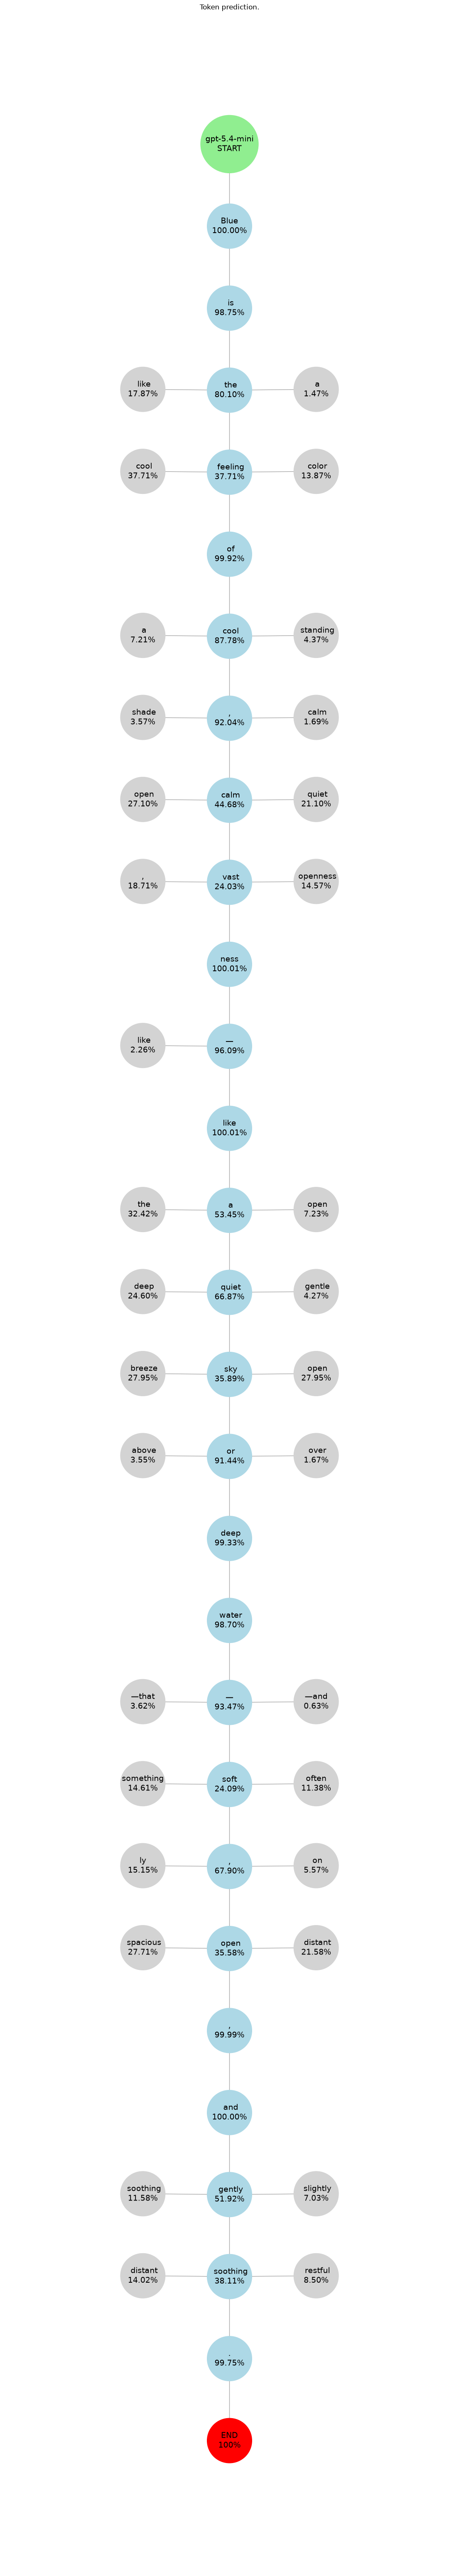

In [9]:
predictor = TokenPredictor(model_name)
predictions = predictor.predict_tokens(message)
G = create_graph(model_name, predictions)
plt = visualise(G)
plt.show()